<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importations des librairies</h3>
</div>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.cluster.hierarchy import dendrogram, linkage

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers</h3>
</div>

In [2]:
sns.set()

data = pd.read_csv('../Ressources/Data.csv')
data.head()

,Pays,"Stabilité politique, rang (%)",PIB par habitant,Population totale,Densité (hab/km²),Prix de production (USD/tonne),Importation de poulet (tonne),% du total des UGB,Émission de CO2eq (kt)
0,Aruba,95.238098,38558.004558,105731,604.083333,0.000000,0.00,0.00,0.000000
1,Afghanistan,0.476190,2952.998916,35688935,54.718328,2495.544526,28937.00,2.04,10.057700
2,Angola,30.476191,9042.117129,30234839,24.251896,2495.544526,265888.30,9.19,91.490500
3,Albanie,59.523811,14155.853728,2898242,104.870693,2495.544526,17515.47,10.54,10.486400
4,Andorre,97.142860,63239.657771,73763,156.942553,0.000000,0.00,0.00,334.388211


In [3]:
data.sort_values(by='Population totale', ascending=False).head()

,Pays,"Stabilité politique, rang (%)",PIB par habitant,Population totale,Densité (hab/km²),Prix de production (USD/tonne),Importation de poulet (tonne),% du total des UGB,Émission de CO2eq (kt)
34,Chine,38.571430,16757.973632,1412354727,148.720044,1681.4,450411.21,19.81,7455.2552
80,Inde,18.571428,7326.606937,1359657400,457.305924,2968.3,17.77,4.25,1413.1787
184,États-Unis,55.714287,66155.555569,332204660,35.704998,1649.3,58075.28,10.92,3727.8145
79,Indonésie,28.095238,11772.574330,267346658,142.393583,2496.3,0.03,66.58,12112.7161
136,Pakistan,1.904762,5031.560607,223273967,289.635179,2097.7,64.48,16.96,3824.8648


In [4]:
data.describe()

,"Stabilité politique, rang (%)",PIB par habitant,Population totale,Densité (hab/km²),Prix de production (USD/tonne),Importation de poulet (tonne),% du total des UGB,Émission de CO2eq (kt)
count,194.000000,194.000000,1.940000e+02,194.000000,194.000000,194.000000,194.000000,194.000000
mean,49.248895,25102.678060,3.866873e+07,355.058038,2508.408157,59326.243763,19.057268,334.388211
std,28.466196,25829.253000,1.455743e+08,1686.982738,1622.871988,132558.203316,21.724347,1154.016685
min,0.476190,880.993440,1.086900e+04,0.136855,0.000000,0.000000,0.000000,0.000000
25%,24.880953,5704.106099,1.502095e+06,36.435839,1627.250000,634.957500,4.947500,10.507100
50%,48.809525,15480.442736,7.227468e+06,85.626324,2495.544526,9509.625000,11.470000,59.117400
75%,73.690477,35438.472280,2.677462e+07,215.174933,2665.475000,46098.305000,22.580000,261.090300
max,100.000000,133500.278959,1.412355e+09,21051.948052,16516.500000,788451.840000,100.000000,12112.716100


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.3 - Préparation des données</h3>
</div>

In [5]:
#On enlève les outliers
outliers = ['Singapour','Indonésie','Inde','Chine','Chine - RAS de Hong-Kong','Chine - RAS de Macao', 'États-Unis','Brésil','Japon','Pakistan','Mexique','Iran, République islamique d’','Fédération de Russie']
data = data[~data['Pays'].isin(outliers)]

In [6]:
#Mettre les noms des pays en index
data = data.set_index('Pays')
names = data.index
features = data.columns
X = data.values

In [7]:
type(X)

numpy.ndarray

In [8]:
X.shape

(181, 8)

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - ACP (Analyse en composantes principales)</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Scaling des données</h3>
</div>

In [9]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled)
data_scaled.describe().round(2).loc[["mean", "std"], :]

,0,1,2,3,4,5,6,7
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Instanciation de l'ACP</h3>
</div>

In [10]:
n_components = 6
pca = PCA(n_components=n_components)
pca.fit(data_scaled)

,n_components,6
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Variance cumulée</h3>
</div>

In [11]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree_cum = scree.cumsum().round()
scree_cum

array([25., 46., 61., 73., 84., 92.])

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Eboulis des valeurs propres</h3>
</div>

In [12]:
x_list = range(1, n_components+1)

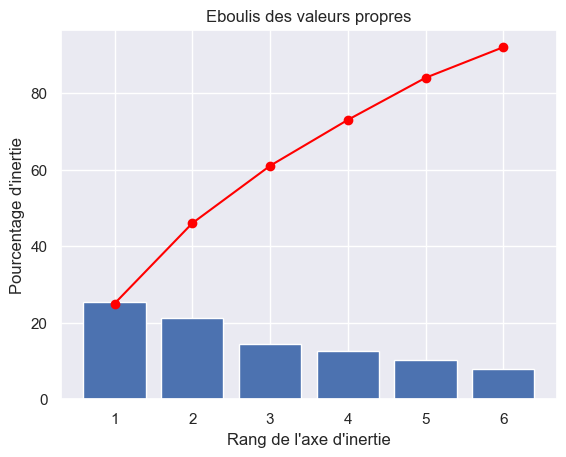

In [37]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("Rang de l'axe d'inertie")
plt.ylabel("Pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.5 - Composantes de l'ACP</h3>
</div>

In [14]:
pcs = pd.DataFrame(pca.components_)
pcs

,0,1,2,3,4,5,6,7
0,-0.509278,-0.292721,0.577078,-0.090398,-0.091790,0.257069,-0.071112,0.483934
1,0.349018,0.587147,0.139775,0.260387,-0.292580,0.438557,0.217168,0.347863
2,-0.236478,-0.112490,0.021322,0.568326,0.321809,-0.135373,0.697199,-0.000768
3,-0.012974,0.188299,-0.044311,-0.440173,0.729746,0.465125,0.139606,-0.017289
4,0.025650,-0.163349,-0.290985,-0.569302,-0.361615,-0.104000,0.602301,0.243996
5,-0.301843,-0.203213,-0.295008,0.132119,-0.329942,0.657316,0.045562,-0.469158


In [15]:
pcs.columns = features
pcs.index = [f"F{i}" for i in x_list]
pcs.T

,F1,F2,F3,F4,F5,F6
"Stabilité politique, rang (%)",-0.509278,0.349018,-0.236478,-0.012974,0.025650,-0.301843
PIB par habitant,-0.292721,0.587147,-0.112490,0.188299,-0.163349,-0.203213
Population totale,0.577078,0.139775,0.021322,-0.044311,-0.290985,-0.295008
Densité (hab/km²),-0.090398,0.260387,0.568326,-0.440173,-0.569302,0.132119
Prix de production (USD/tonne),-0.091790,-0.292580,0.321809,0.729746,-0.361615,-0.329942
Importation de poulet (tonne),0.257069,0.438557,-0.135373,0.465125,-0.104000,0.657316
% du total des UGB,-0.071112,0.217168,0.697199,0.139606,0.602301,0.045562
Émission de CO2eq (kt),0.483934,0.347863,-0.000768,-0.017289,0.243996,-0.469158


<Axes: >

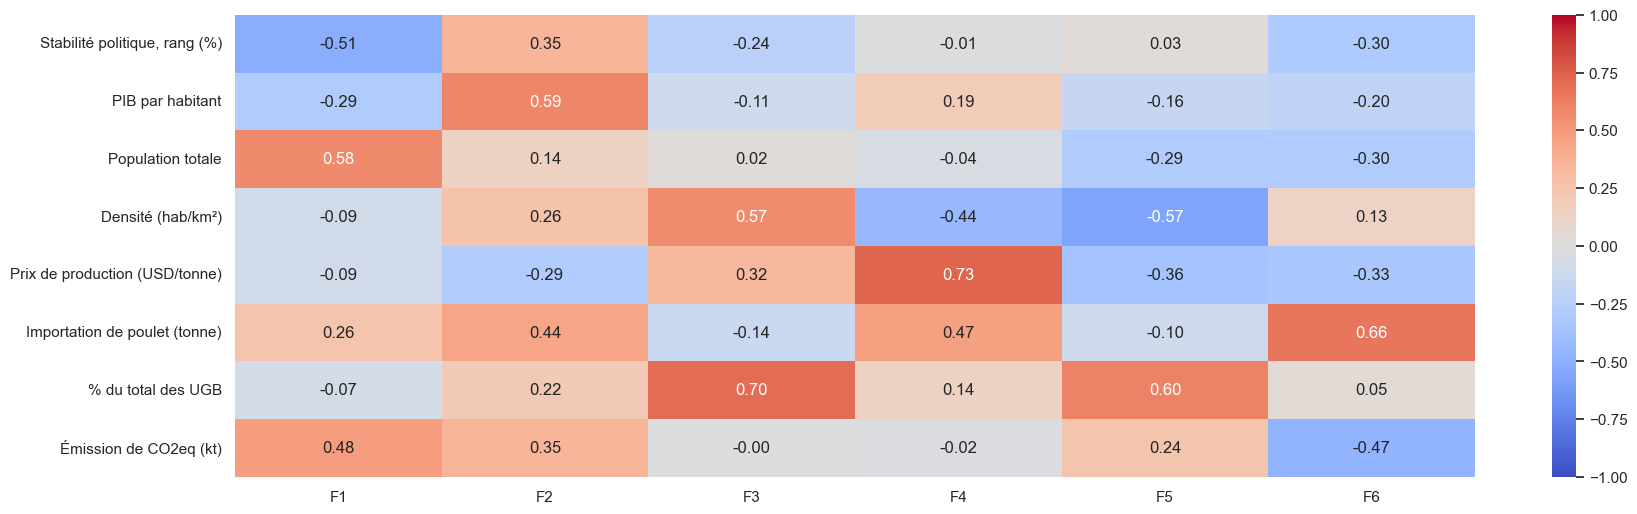

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.5 - Graphe des corrélations</h3>
</div>

In [17]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

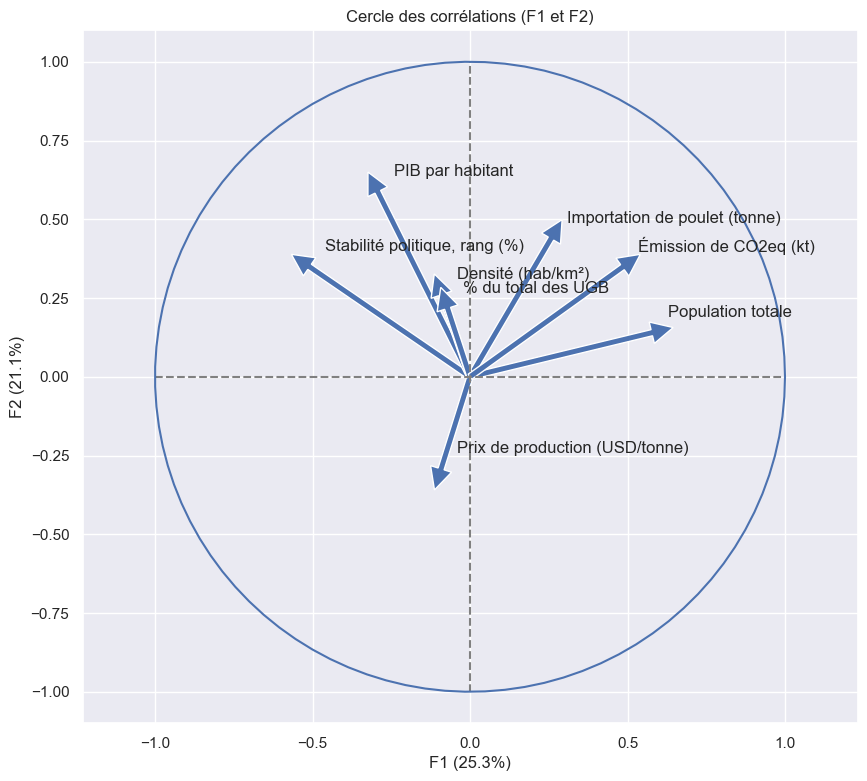

In [18]:
correlation_graph(pca, (0,1), features)

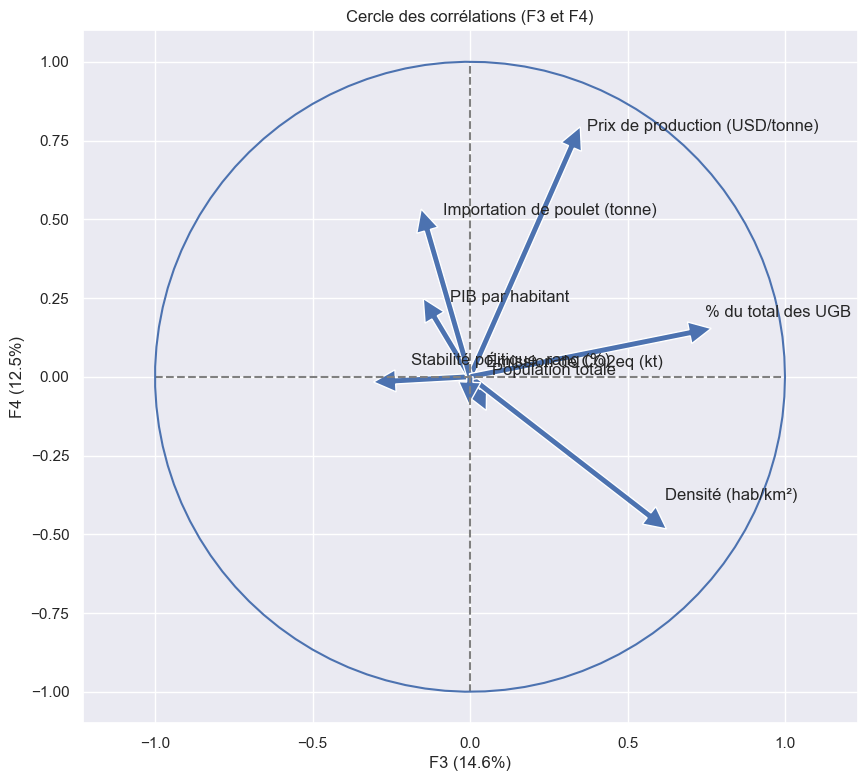

In [19]:
correlation_graph(pca, (2,3), features)

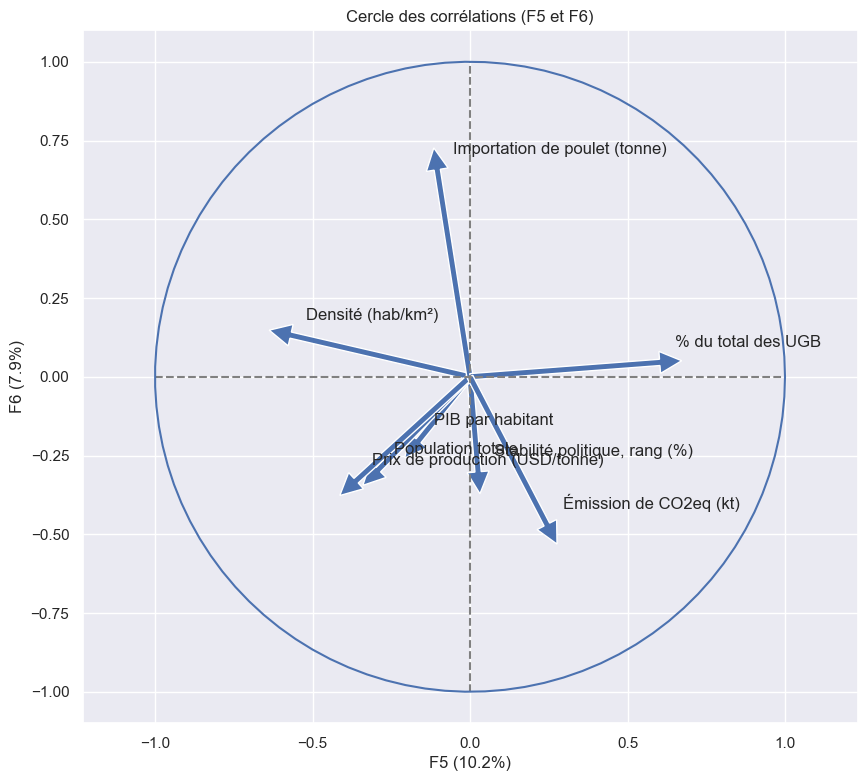

In [20]:
correlation_graph(pca, (4,5), features)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.6 - Projections</h3>
</div>


In [21]:
data_proj = pca.transform(data_scaled)

In [22]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()



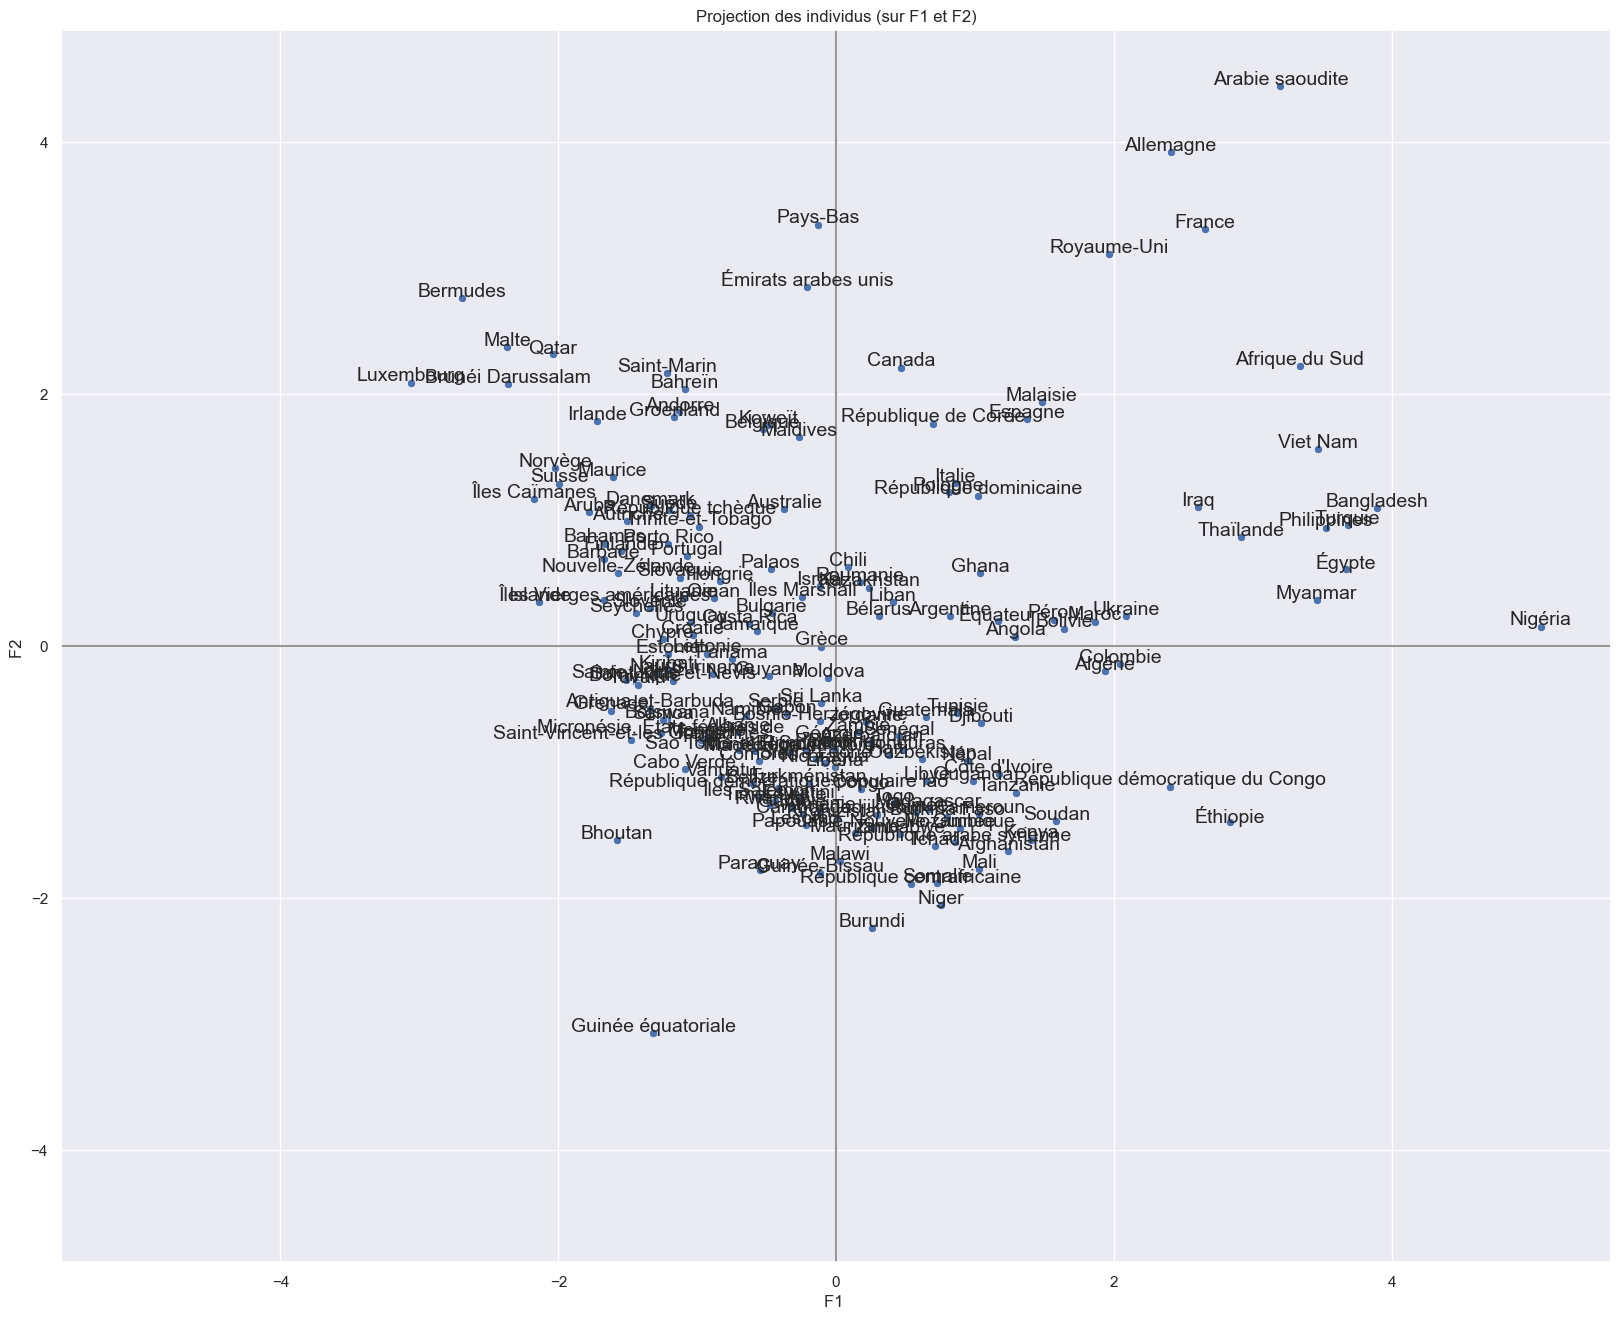

In [38]:
display_factorial_planes(data_proj, [0,1], labels=names, figsize=(20,16))

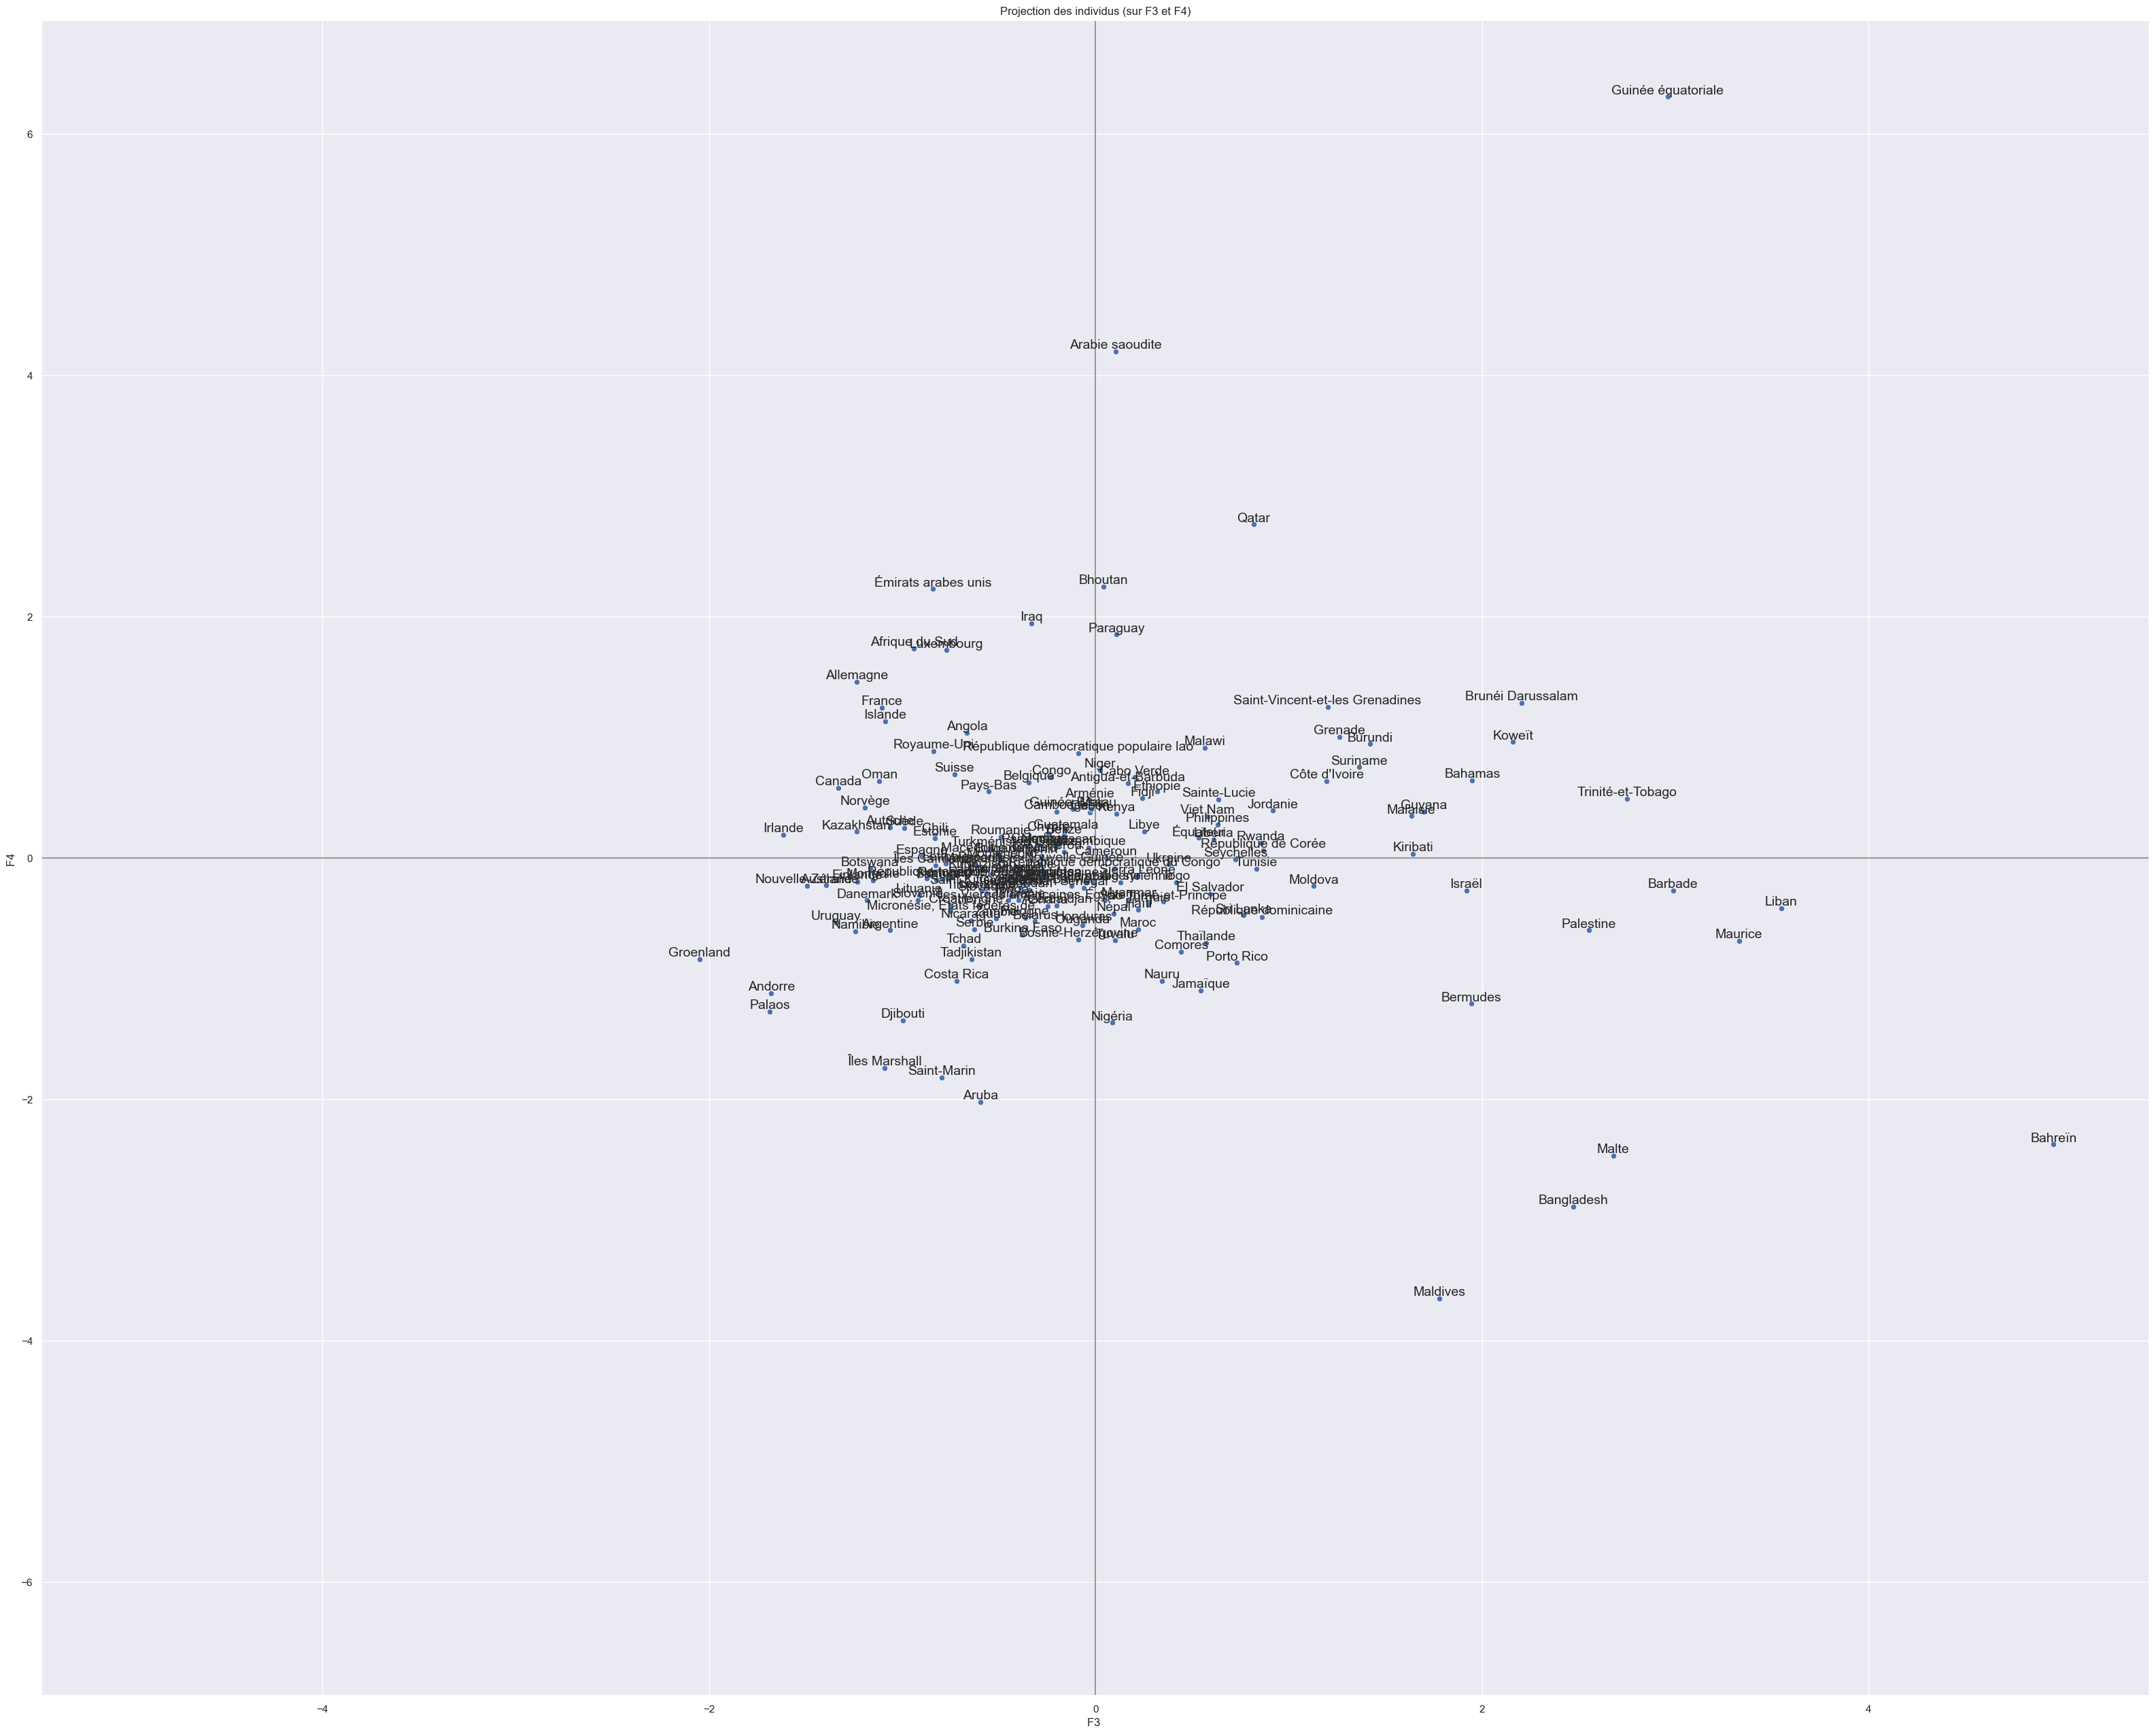

In [24]:
display_factorial_planes(data_proj, [2,3], labels=names, figsize=(40,32))

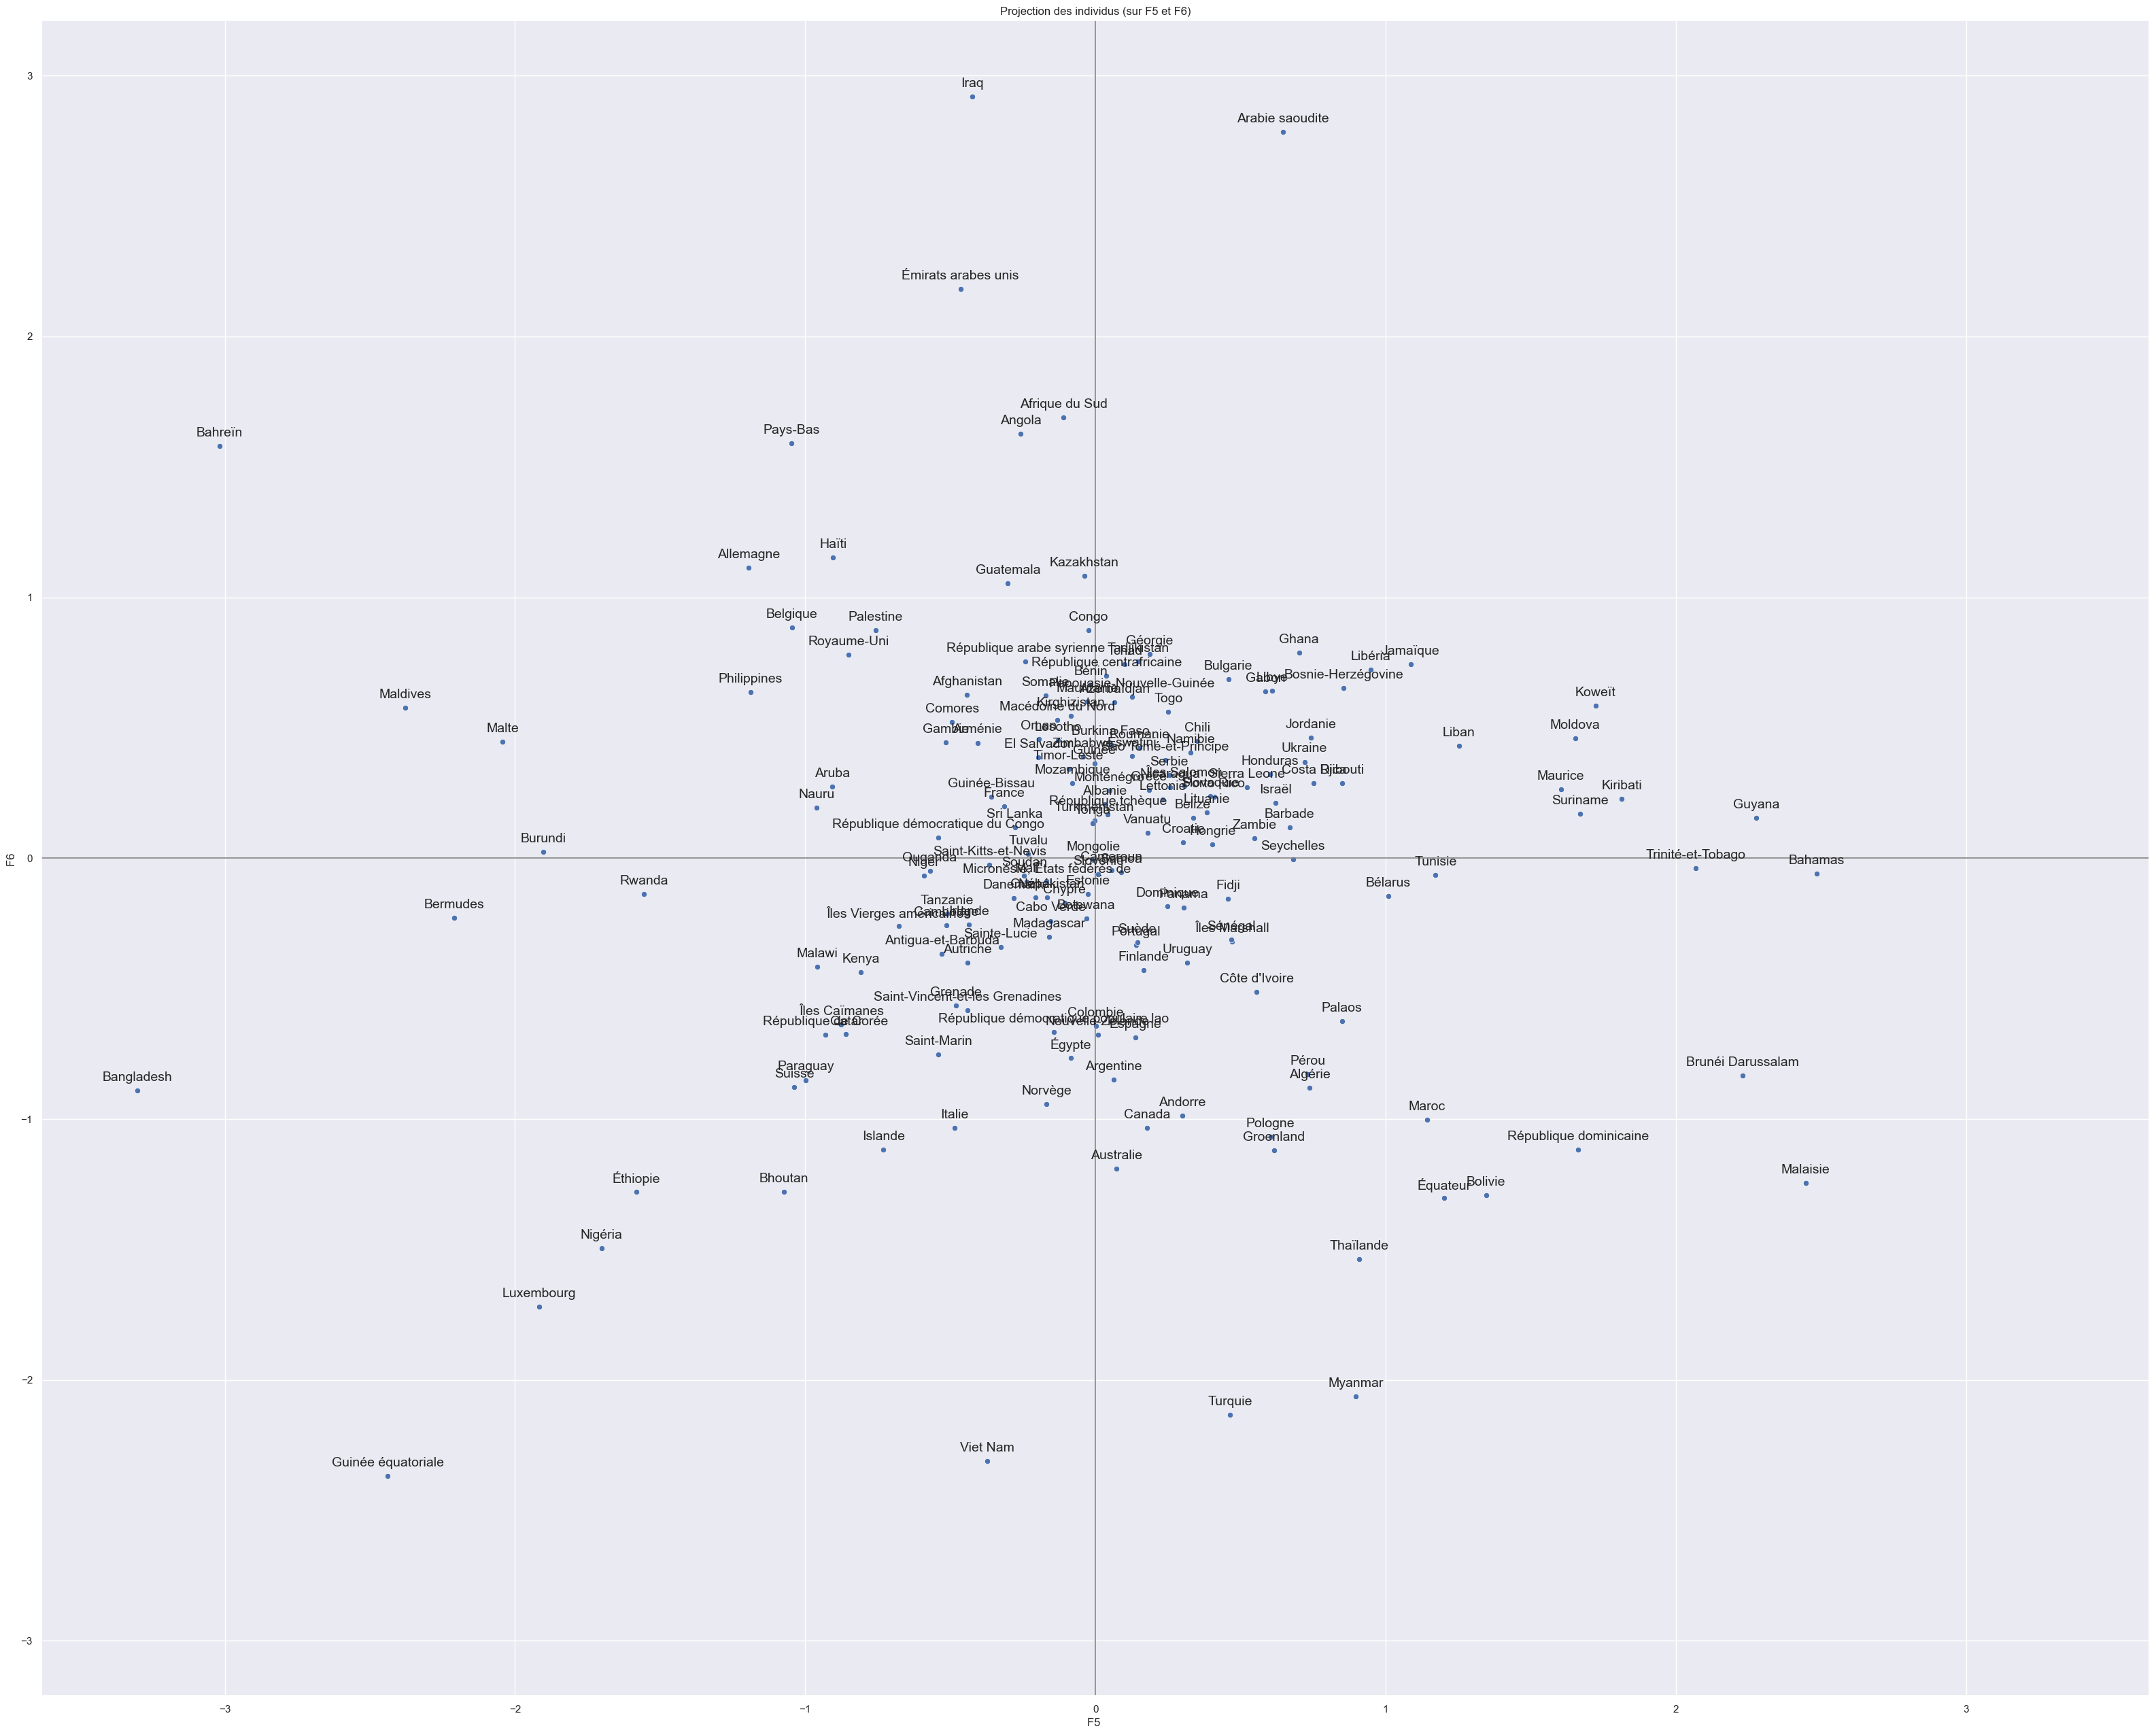

In [25]:
display_factorial_planes(data_proj, [4,5], labels=names, figsize=(40,32))

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">3 - Partitionnement</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Classification hiérarchique</h3>
</div>

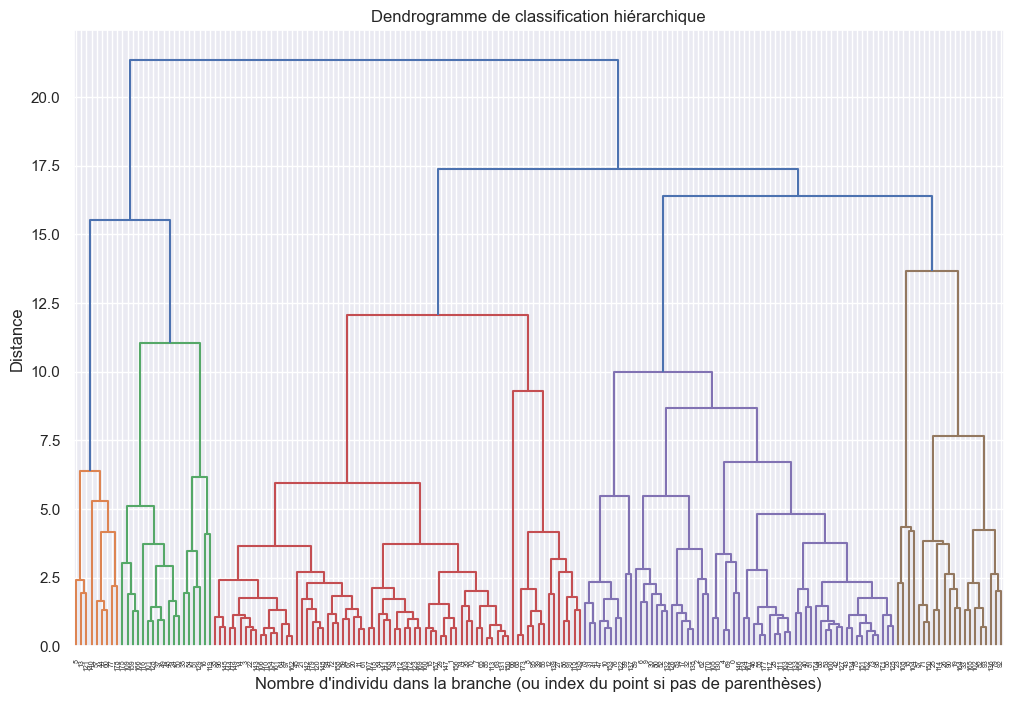

In [26]:
Z = linkage(data_scaled, method="ward")

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z,ax=ax)

plt.title("Dendrogramme de classification hiérarchique")
plt.xlabel("Nombre d'individu dans la branche (ou index du point si pas de parenthèses)")
plt.ylabel("Distance")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - K-means</h3>
</div>

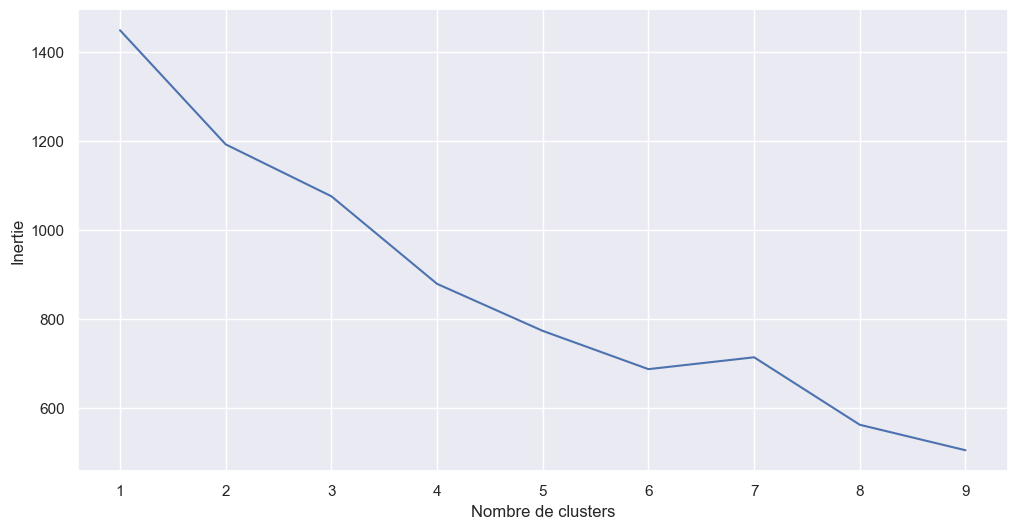

In [27]:
# Une liste vide pour enregistrer les inerties :  
intertia_list = [ ]

# Notre liste de nombres de clusters : 
k_list = range(1, 10)

# Pour chaque nombre de clusters : 
for k in k_list : 
    
    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k)
    
    # On entraine
    kmeans.fit(data_scaled)
    
    # On enregistre l'inertie obtenue : 
    intertia_list.append(kmeans.inertia_)
    
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("Inertie")
ax.set_xlabel("Nombre de clusters")

ax = plt.plot(k_list, intertia_list)

In [28]:
# On instancie notre Kmeans: 
kmeans = KMeans(n_clusters=6)

# On l'entraine : 
kmeans.fit(data_scaled)

# On peut stocker nos clusters dans une variable labels_kmeans : 
labels = kmeans.labels_

# On peut stocker nos centroids dans une variable : 
centroids = kmeans.cluster_centers_

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=3)
pca.fit(X_scaled)
X_proj = pca.transform(X_scaled)
X_proj = pd.DataFrame(X_proj, columns = ["PC1", "PC2", "PC3"])
X_proj[:10]

,PC1,PC2,PC3
0,-1.776778,1.064914,-0.593584
1,1.240190,-1.624192,-0.252502
2,1.290945,0.076642,-0.665558
3,-0.709372,-0.682300,-0.409180
4,-1.127440,1.859810,-1.677800
5,-0.207066,2.848093,-0.840030
6,0.817891,0.238105,-1.063771
7,-0.116795,-1.305393,-0.031014
8,-1.340573,-0.494503,0.167014
9,-0.377578,1.091229,-1.392826


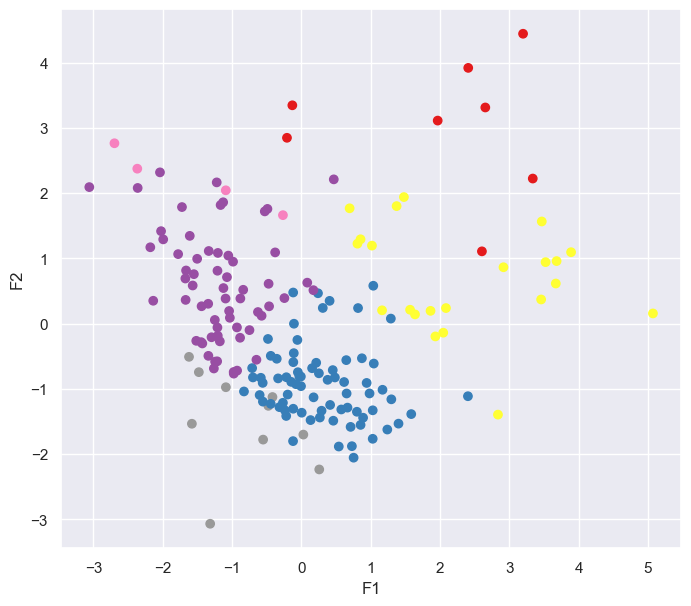

In [30]:
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1")
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

In [31]:
# On utilise bien le scaler déjà entrainé : 
centroids_scaled = scaler.fit_transform(centroids)

# et on utilise l'ACP déjà entrainée : 
centroids_proj = pca.transform(centroids_scaled)

# Création d'un dataframe pour plus de clarté:
centroids_proj = pd.DataFrame(centroids_proj, 
                              columns = ["F1", "F2", "F3"], 
                              index=["cluster_0", "cluster_1", "cluster_2", "cluster_3", "cluster_4", "cluster_5"])

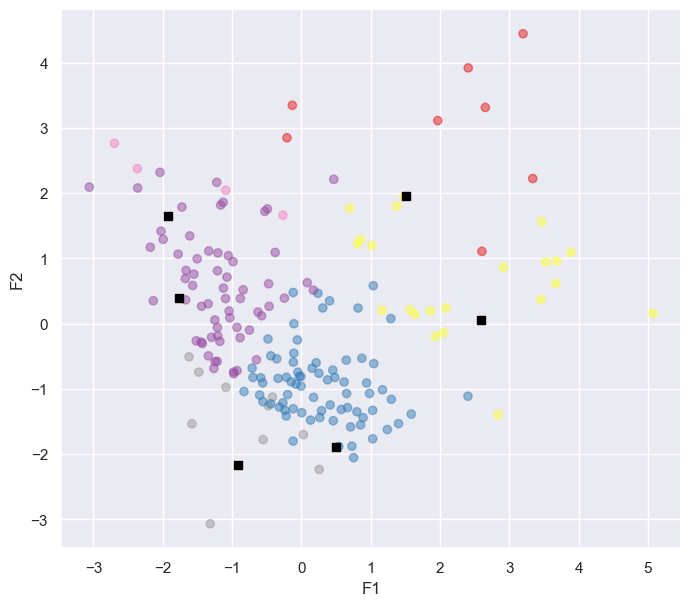

In [32]:
# On définit notre figure et son axe : 
fig, ax = plt.subplots(1,1, figsize=(8,7))

X_ = np.array(X_proj)
x, y = axis = (0,1 )

# On affiche nos individus, avec une transparence de 50% (alpha=0.5) : 
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1", alpha =0.5)

# On affiche nos centroides, avec une couleur noire (c="black") et une frome de carré (marker="c") : 
ax.scatter(centroids_proj.iloc[:, 0], centroids_proj.iloc[:, 1],  marker="s", c="black" )

# On spécifie les axes x et y :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

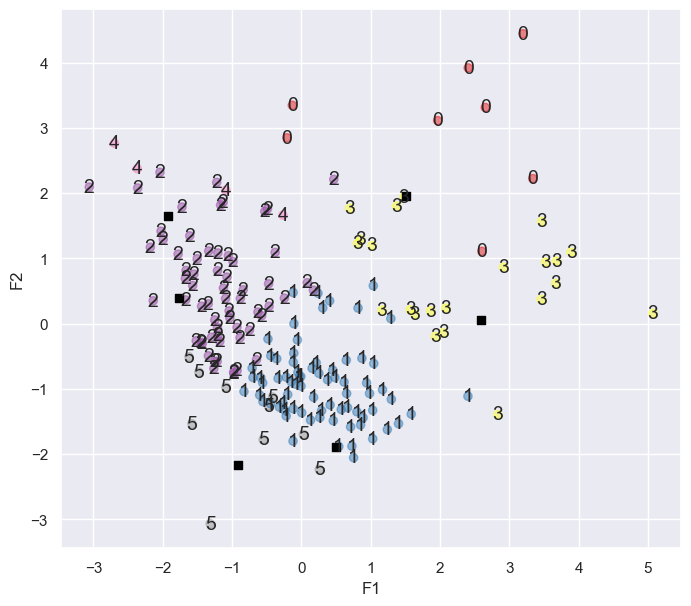

In [33]:
# On définit notre figure et son axe : 
fig, ax = plt.subplots(1,1, figsize=(8,7))

X_ = np.array(X_proj)
x, y = axis = (0,1 )

# On affiche nos individus, avec une transparence de 50% (alpha=0.5) : 
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1", alpha =0.5)

# On affiche nos centroides, avec une couleur noire (c="black") et une frome de carré (marker="c") : 
ax.scatter(centroids_proj.iloc[:, 0], centroids_proj.iloc[:, 1],  marker="s", c="black" )

# On affiche les labels :
for i,(x,y) in enumerate(X_[:,[x,y]]):
    ax.text(x, y, labels[i], fontsize='14', ha='center',va='center') 

# On spécifie les axes x et y :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

Text(0.5, 0, 'F3')

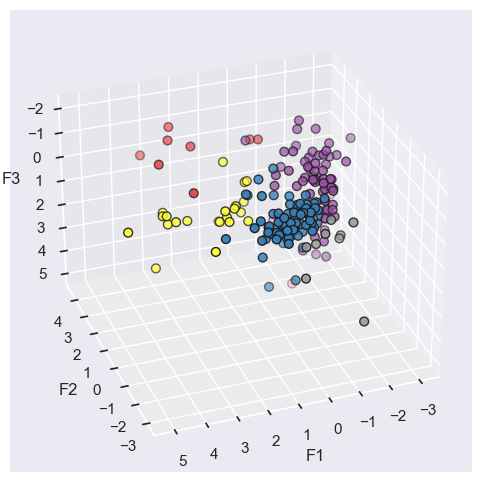

In [34]:
# On définit notre figure et notre axe différemment : 
fig= plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# On affiche nos points : 
ax.scatter(
    X_proj.iloc[:, 0],
    X_proj.iloc[:, 1],
    X_proj.iloc[:, 2],
    c=labels, cmap="Set1", edgecolor="k", s=40)

# On spécifie le nom des axes : 
ax.set_xlabel("F1")
ax.set_ylabel("F2")
ax.set_zlabel("F3")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Application</h3>
</div>

In [35]:
#On réalise un tableau de contingence entre les clusters et les features
df = pd.DataFrame({"Pays" : data.index, "Cluster": labels})
df.head()

,Pays,Cluster
0,Aruba,2
1,Afghanistan,1
2,Angola,1
3,Albanie,1
4,Andorre,2


In [36]:
for i in range(6) :
    # on fait une selection
    sub_df = df.loc[df.Cluster == i]

    # le cluster en question
    print(f"cluster : {i}")

    # on extrait les noms et les themes de chaque ligne
    pays_list = sub_df.Pays.values
    txt = [f" {n}" for n in pays_list]

    # on transforme en str
    txt = "\n".join(txt)

    # on print
    print(txt)
    print("\n\n")

cluster : 0
 Émirats arabes unis
 Allemagne
 France
 Royaume-Uni
 Iraq
 Pays-Bas
 Arabie saoudite
 Afrique du Sud



cluster : 1
 Afghanistan
 Angola
 Albanie
 Argentine
 Arménie
 Azerbaïdjan
 Bénin
 Burkina Faso
 Bosnie-Herzégovine
 Bélarus
 Belize
 République centrafricaine
 Côte d'Ivoire
 Cameroun
 République démocratique du Congo
 Congo
 Comores
 Djibouti
 Gabon
 Géorgie
 Ghana
 Guinée
 Gambie
 Guinée-Bissau
 Grèce
 Guatemala
 Guyana
 Honduras
 Haïti
 Israël
 Jordanie
 Kazakhstan
 Kenya
 Kirghizistan
 Cambodge
 Liban
 Libéria
 Libye
 Sri Lanka
 Lesotho
 Moldova
 Madagascar
 Macédoine du Nord
 Mali
 Monténégro
 Mozambique
 Mauritanie
 Niger
 Nicaragua
 Népal
 Papouasie-Nouvelle-Guinée
 Palestine
 Soudan
 Sénégal
 Îles Salomon
 Sierra Leone
 El Salvador
 Somalie
 Serbie
 Sao Tomé-et-Principe
 Eswatini
 République arabe syrienne
 Tchad
 Togo
 Tadjikistan
 Turkménistan
 Timor-Leste
 Tunisie
 Tanzanie
 Ouganda
 Ouzbékistan
 Vanuatu
 Zambie
 Zimbabwe



cluster : 2
 Aruba
 Andorre
 Antig

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">FIN</h2>
</div>